# Phase 2: Tactical Player Analysis 📊
> **Target Match:** FIFA World Cup 2022 Final (Argentina vs France)  
> **Objective:** Extract and visualize individual player influence using spatial data.

---
### 🛠️ Step 1: Data Preparation & Filtering
We will filter the event data to focus on specific actions (Passes & Shots) for key players like **Lionel Messi**.

In [7]:
from statsbombpy import sb
import pandas as pd

# 1. Fetch data again (since this is a new file)
MATCH_ID = 3869685
print("Connecting to StatsBomb... Downloading Match Events.")
events = sb.events(match_id=MATCH_ID)

# 2. Now run your filtering code
messi_passes = events[(events.type == 'Pass') & 
                      (events.player == 'Lionel Andrés Messi Cuccittini')].copy()

# 3. Extract coordinates
messi_passes['x'] = messi_passes.location.apply(lambda loc: loc[0])
messi_passes['y'] = messi_passes.location.apply(lambda loc: loc[1])
messi_passes['end_x'] = messi_passes.pass_end_location.apply(lambda loc: loc[0])
messi_passes['end_y'] = messi_passes.pass_end_location.apply(lambda loc: loc[1])

messi_passes['pass_outcome'] = messi_passes.pass_outcome.fillna('Complete')

print(f"Success! Found {len(messi_passes)} passes for Messi.")
print(messi_passes[['x', 'y', 'end_x', 'end_y', 'pass_outcome']].head())

Connecting to StatsBomb... Downloading Match Events.
Success! Found 60 passes for Messi.
        x     y  end_x  end_y pass_outcome
36   76.6  35.7  116.2    8.9     Complete
39   99.3  57.3   96.7   49.8     Complete
52   67.9  59.0   49.0   60.3     Complete
62   81.8  65.2   70.2   67.7     Complete
103  39.2  48.1   65.3   35.4     Complete


### Step 2: Spatial Visualization of Playmaking
> "Visualizing Messi's influence: We are mapping every pass to see how he dictated the tempo of the World Cup Final."

In this section, we use the `mplsoccer` library to project Messi's raw coordinates onto a professional-grade pitch. 

**Technical Configuration:**
* **Pitch Type:** StatsBomb (120x80 units).
* **Visual Elements:** * `Arrows`: Indicate the direction and length of each pass.
    * `Scatter Points`: Represent the starting location where Messi received the ball.
* **Branding:** Dark theme for high-contrast tactical analysis.

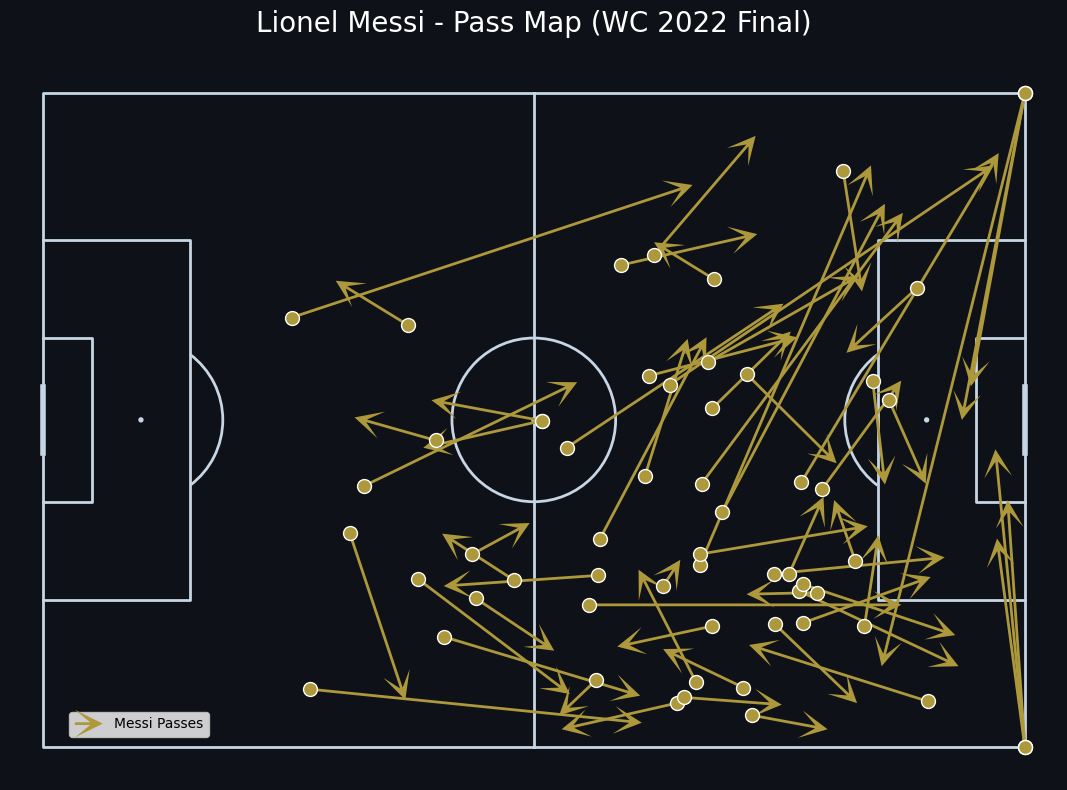

In [8]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 1. Setup the pitch (Professional Dark Theme)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5e4')
fig, ax = pitch.draw(figsize=(13, 8))
fig.set_facecolor('#0e1117')

# 2. Plot the passes
# We will draw arrows for each pass
pitch.arrows(messi_passes.x, messi_passes.y,
             messi_passes.end_x, messi_passes.end_y, 
             width=2, headwidth=10, headlength=10, 
             color='#ad993c', ax=ax, label='Messi Passes')

# 3. Add a scatter plot for the start location (the dot)
pitch.scatter(messi_passes.x, messi_passes.y, 
              s=100, color='#ad993c', edgecolors='white', linewidth=1, alpha=1, ax=ax)

# 4. Add Title and Branding
plt.title("Lionel Messi - Pass Map (WC 2022 Final)", color='white', size=20, pad=20)
plt.legend(loc='lower left', bbox_to_anchor=(0.05, 0.05))

# 5. Show the masterpiece
plt.show()

### 📊 Step 3: Performance Metrics - Pass Accuracy Mapping
> "In high-stakes matches, efficiency is everything. We now differentiate between successful distribution and turnovers."

By categorizing passes based on their `pass_outcome`, we can visualize:
1. **Successful Delivery (#00ff41):** Highlighting Messi's reliability in ball progression.
2. **Turnovers & Interceptions (#ff003c):** Identifying where the opposition (France) managed to neutralize the threat.

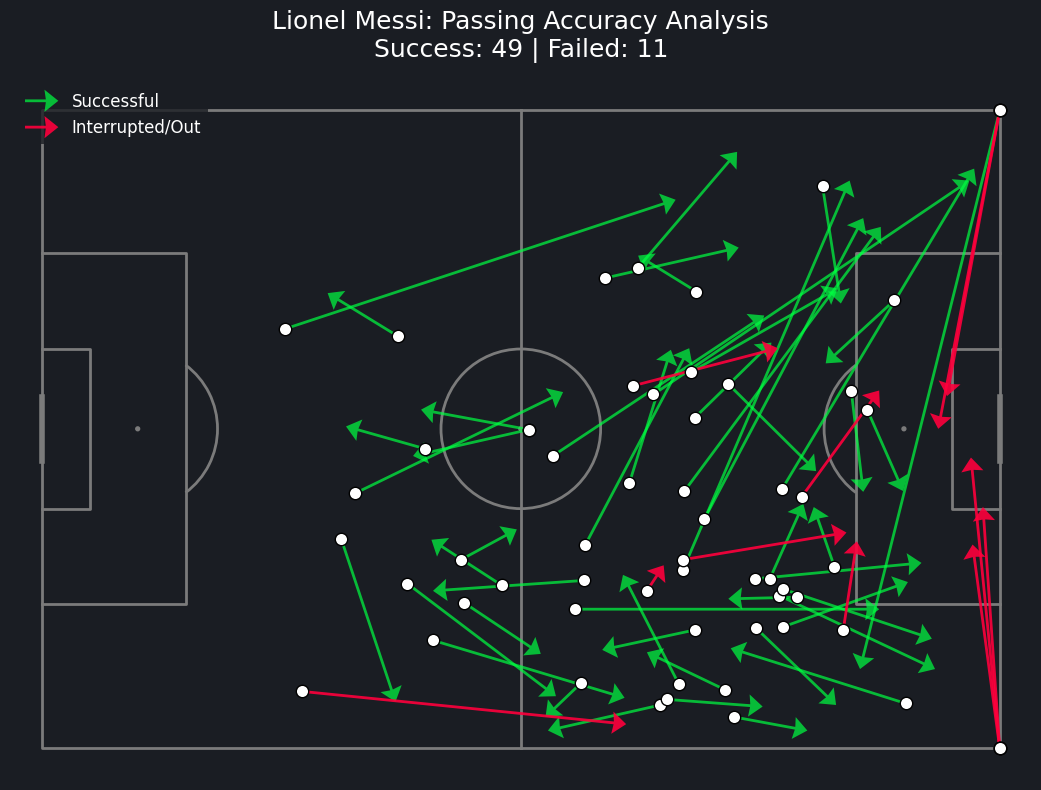

In [9]:
# 1. Split the data into successful and unsuccessful passes
mask_complete = messi_passes.pass_outcome == 'Complete'
complete = messi_passes[mask_complete]
incomplete = messi_passes[~mask_complete] # Any outcome that isn't 'Complete'

# 2. Setup the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1d23', line_color='#7b7b7b')
fig, ax = pitch.draw(figsize=(13, 8))
fig.set_facecolor('#1a1d23')

# 3. Plot Successful Passes (Green/Gold)
pitch.arrows(complete.x, complete.y, complete.end_x, complete.end_y, 
             width=2, headwidth=8, color='#00ff41', ax=ax, label='Successful', alpha=0.7)

# 4. Plot Unsuccessful Passes (Red)
pitch.arrows(incomplete.x, incomplete.y, incomplete.end_x, incomplete.end_y, 
             width=2, headwidth=8, color='#ff003c', ax=ax, label='Interrupted/Out', alpha=0.9)

# 5. Add scatter for start positions
pitch.scatter(messi_passes.x, messi_passes.y, s=80, color='white', edgecolors='black', ax=ax)

# 6. Title and Legend
plt.legend(facecolor='#1a1d23', edgecolor='none', labelcolor='white', loc='upper left', fontsize=12)
plt.title(f"Lionel Messi: Passing Accuracy Analysis\nSuccess: {len(complete)} | Failed: {len(incomplete)}", 
          color='white', size=18, pad=15)

plt.show()

### Step 4: Player Territorial Dominance (Heatmap)
> "Positioning is everything. To control the game, you must control the space."

Now, we shift from 'actions' to 'presence'. This Heatmap visualizes Messi's density on the pitch, showing the specific zones where he spent the most time and influenced the match.

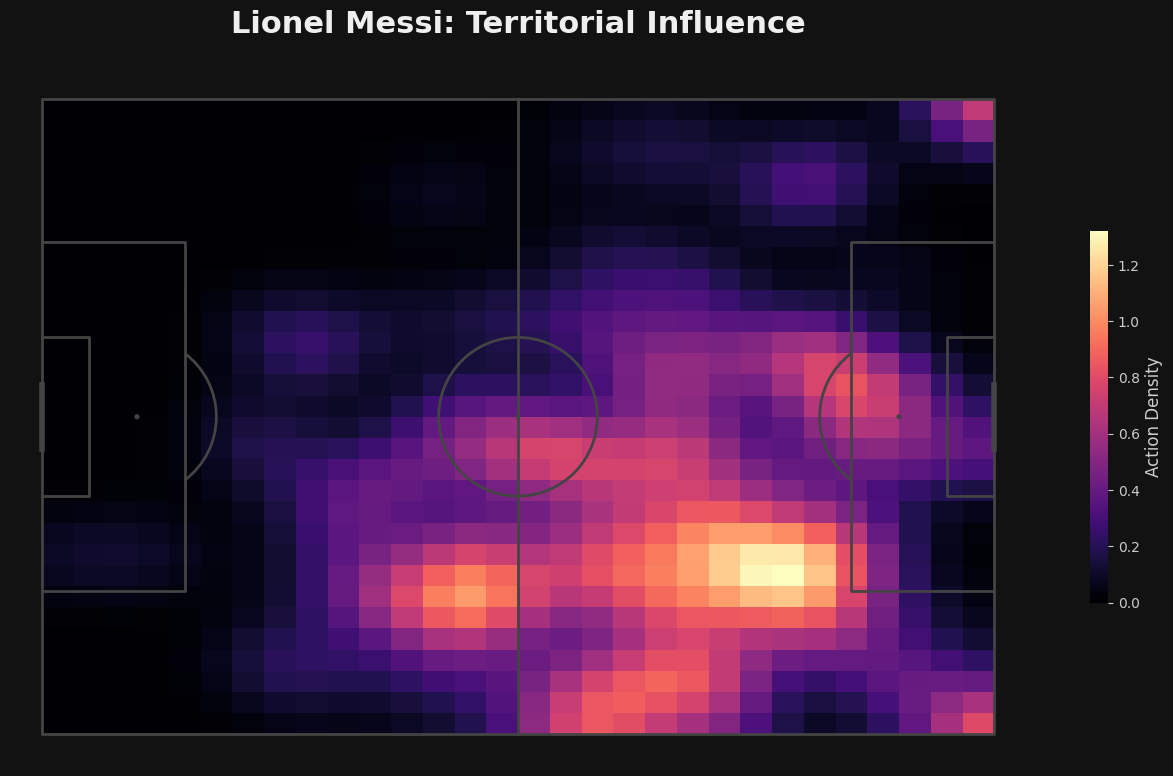

In [10]:
from scipy.ndimage import gaussian_filter

messi_id = 5503

messi_events = events[(events.player_id == messi_id) & (events.location.notnull())].copy()

messi_events['x'] = messi_events.location.apply(lambda loc: loc[0])
messi_events['y'] = messi_events.location.apply(lambda loc: loc[1])


# 1. Setup the pitch with a softer dark theme
pitch = Pitch(pitch_type='statsbomb', line_zorder=2, 
              pitch_color='#121212', line_color='#444444') # Grey lines for less contrast
fig, ax = pitch.draw(figsize=(13, 8))
fig.set_facecolor('#121212')

# 2. Create the Heatmap with "Magma" colormap
# This provides a smooth transition from dark purple to soft orange
bin_statistic = pitch.bin_statistic(messi_events.x, messi_events.y, 
                                    statistic='count', bins=(30, 30)) # More bins for more detail
bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], sigma=1.5)

# 3. Plot the heatmap with 'magma' - elegant and professional
pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='magma', edgecolors='none')

# 4. Add a styled color bar
cbar = fig.colorbar(pcm, ax=ax, shrink=0.5)
cbar.set_label('Action Density', color='#cccccc', size=12)
cbar.outline.set_visible(False)
cbar.ax.yaxis.set_tick_params(color='#cccccc', labelcolor='#cccccc')

# 5. Title with a cleaner font
plt.title("Lionel Messi: Territorial Influence", color='#efefef', size=22, pad=25, weight='bold')
plt.show()

### 🏆 Step 5: The Master Analysis (Heatmap + Key Passes)
> "Presence is good, but creation is better. This combined view proves that Messi's positioning was directly linked to Argentina's goal-scoring opportunities."

By overlaying **Key Passes** (passes leading to shots) on top of the **Territorial Heatmap**, we identify the 'Danger Zones' where Messi was most creative.

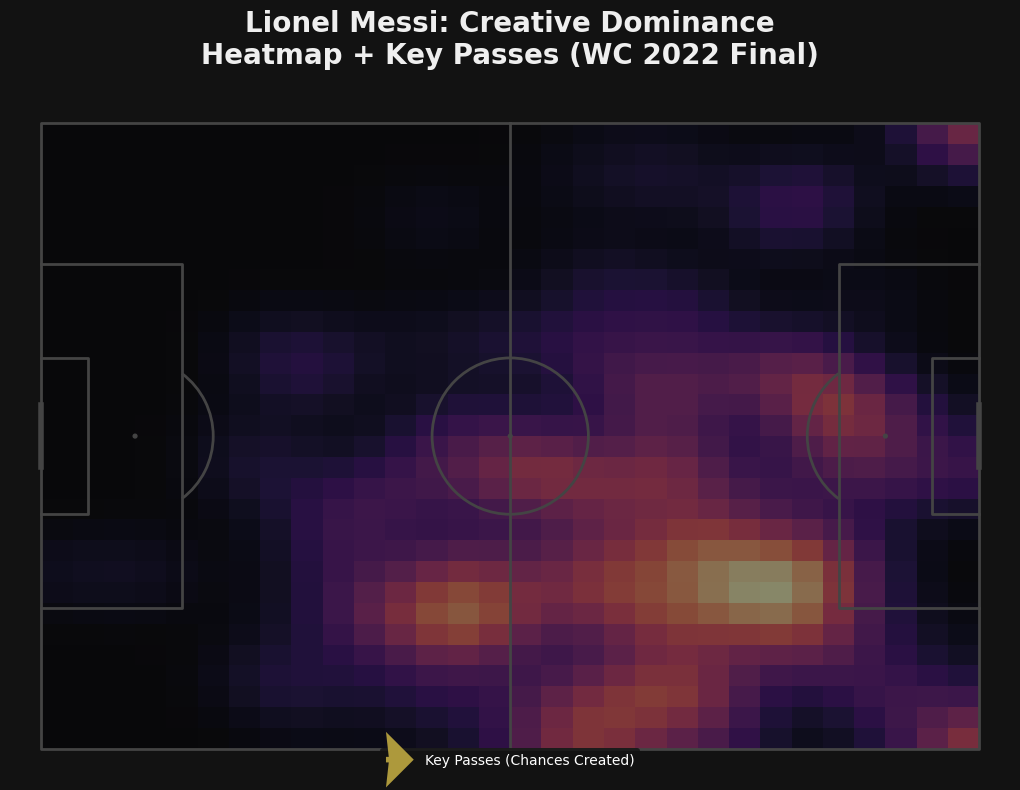

In [11]:
# 1. Filter Key Passes
# In StatsBomb data, a 'Key Pass' is linked to a shot via 'shot_key_pass_id'
key_passes = messi_passes[messi_passes.shot_key_pass_id.notnull()].copy()

# 2. Setup the Pitch with a sleek dark theme
pitch = Pitch(pitch_type='statsbomb', line_zorder=2, 
              pitch_color='#121212', line_color='#444444')
fig, ax = pitch.draw(figsize=(13, 8))
fig.set_facecolor('#121212')

# 3. Create and Plot the Heatmap (Background Layer)
# We use a Gaussian filter to smooth the density of Messi's total actions
bin_statistic = pitch.bin_statistic(messi_events.x, messi_events.y, statistic='count', bins=(30, 30))
bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], sigma=1.5)
pitch.heatmap(bin_statistic, ax=ax, cmap='magma', alpha=0.5) # Semi-transparent to make arrows pop

# 4. Plot Key Passes (The Golden Arrows)
# These represent the high-value actions that led directly to goal attempts
pitch.arrows(key_passes.x, key_passes.y, key_passes.end_x, key_passes.end_y, 
             width=4, headwidth=10, color='#ad993c', ax=ax, 
             label='Key Passes (Chances Created)')

# 5. Highlight Start Locations
# Adding distinct markers where Messi initiated these creative sparks
pitch.scatter(key_passes.x, key_passes.y, s=150, color='#ad993c', 
              edgecolors='white', linewidth=1, ax=ax)

# 6. Final Branding and Styling
plt.title("Lionel Messi: Creative Dominance\nHeatmap + Key Passes (WC 2022 Final)", 
          color='#efefef', size=20, pad=20, weight='bold')

plt.legend(facecolor='#121212', edgecolor='none', labelcolor='white', loc='lower center')

# Show the tactical masterpiece
plt.show()